<a href="https://colab.research.google.com/github/Ayushsan1/Pytorch-Implementation-and-Foundation/blob/main/04_Pytorch_Custom_Datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

####In our last Notebook ( Computer Vision 03) , we built a Computer Vision model on an built in dataset in PyTorch (FashionMNIST).
The steps are Similar as most of ML model:
Find a Dataset --> turn dataset into Numbers --> Build a model to find patter in those numbers ---> then get Predictions through that.

PyTorch has many built in Datasets but some times we also need to use our own custom Dataset, Lets learn how we can do that exactly.

 if we were building a food image classification app like Nutrify, our custom dataset might be images of food.

In [26]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [3]:
torch.__version__

'2.11.0+cu128'

In [4]:
#Device agnostic code
if torch.cuda.is_available():
  device = "cuda"
else:
  device = "cpu"

In [5]:
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...")
        zip_ref.extractall(image_path)

Did not find data/pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


One should for training, store dataset in particular manner so that classification and tagging is simple and easy:
Here is the structured format:-

pizza_steak_sushi/ <- overall dataset folder

    train/ <- training images
        pizza/ <- class name as folder name
            image01.jpeg
            image02.jpeg
            ...
        steak/
            image24.jpeg
            image25.jpeg
            ...
        sushi/
            image37.jpeg
            ...
    test/ <- testing images
        pizza/
            image101.jpeg
            image102.jpeg
            ...
        steak/
            image154.jpeg
            image155.jpeg
            ...
        sushi/
            image167.jpeg
            ...

Now we have to use and turn this dataset in such a manner that it is usable in Pytorch operations
We can inspect what's in our data directory by writing a small helper function to walk through each of the subdirectories and count the files present.
For this we will use: os.walk()


In [6]:
import os
def walk_through_dir(dir_path):

  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [7]:
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

Random Image path: data/pizza_steak_sushi/test/sushi/2521706.jpg
Image class: sushi
Image height: 512px
Image width: 384px


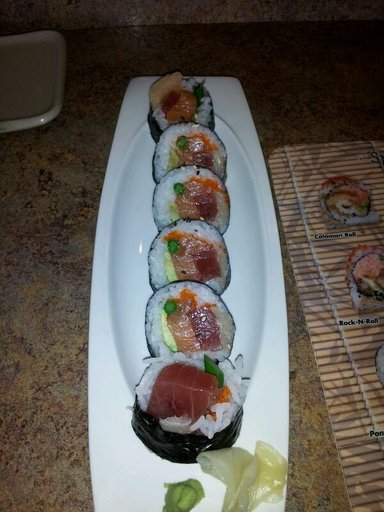

In [12]:
import random
from PIL import Image

random.seed(42)
#Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))

random_image_path = random.choice(image_path_list)
print(f"Random Image path: {random_image_path}")

image_class = random_image_path.parent.stem
img = Image.open(random_image_path)
print(f"Image class: {image_class}")
print(f"Image height: {img.height}px")
print(f"Image width: {img.width}px")

img

### Until now is good as we are performing action into normal python lib but what if we wanted to load our into PyTorch

Before that we need to :-
1. Turn it into Tensors
2. Turn it into `torch.utils.data.Datasets` and `torch.utils.data.DataLoader`

There are several different kind of methods for built in Datasets and DataLoader:
Problem space	Pre-built Datasets and Functions
1. Vision	--> torchvision.datasets
2. Audio --> torchaudio.datasets
3. Text -->	torchtext.datasets
4. Recommendation system --> torchrec.datasets


In [13]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

here we would use torch.vision.\
For resize image we use `transforms.Resize()` like from 512x512 to 64x64
Flip our images randomly on horizontal for data augmentation (a method to chnage or increase the size or diversity of data) - transforms.`RandomHorizantalFlip()`  
Turn images from PIL images to Pytorch Tensors using - `transforms.ToTensor()`

In [20]:
#we would be using torch.transform.compose to compile all these settings

data_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5), #giving 50% chance to flip
    transforms.ToTensor()] #converts all pixel like of 0 - 255 to 0.0 - 1.0
)

#### the aboce is composed transform function we have to implement on images and make it functional on GPU based programming


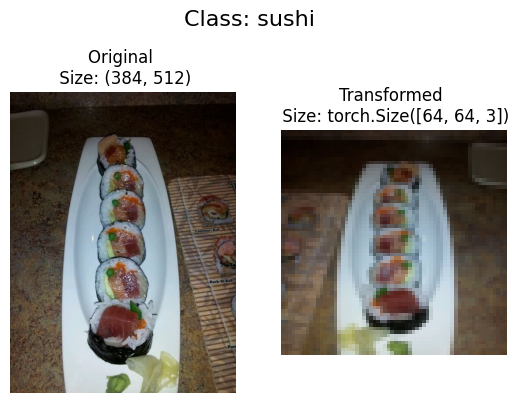

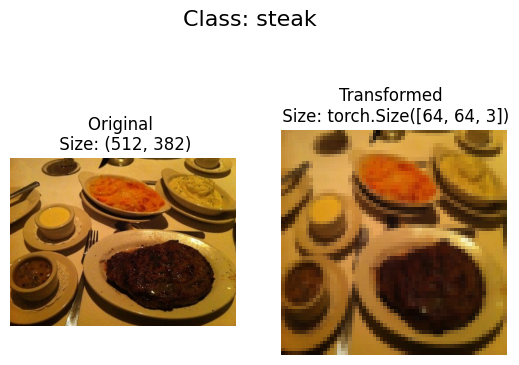

In [34]:
def plot_transformed_images(image_paths, transform, n=2, seed=42):
  random.seed(seed)
  random_image_path = random.sample(image_paths, k=n)

  for image_path in random_image_path:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(1,2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original \n Size: {f.size}")
      ax[0].axis("off")

      #Transform and plot image
      transformed_image = transform(f).permute(1,2,0) #runs the transform function then .permute(1,2,0) changes image t0 (C,H,W) - [pytorch way] from (H, W, C) - [Matplot way]
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Transformed \n Size: {transformed_image.shape}")
      ax[1].axis("off")

      fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_path_list, transform=data_transform, n=2)

## Turning Image data into Image Dataset,  that is capable to used in PyTorch.
Since we have data in standard image classification way (as defiend above) we would use :
- `torchvision.datasets.ImageFolder`

We would making two datasets one of Train and another of Test.

In [35]:
from torchvision import datasets

train_data = datasets.ImageFolder(root = train_dir, transform = data_transform,
                                  target_transform = None)

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform,
                                 target_transform = None)
print(f"Train data:\n{train_data}\nTest data:\n{test_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 225
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 75
    Root location: data/pizza_steak_sushi/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [37]:
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [39]:
#if wanna know class names in form  of indexed dict form
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}